# 04 — Transformer Extension (DistilBERT)

**Course:** Computación y Estructuras Discretas III — 2026-1  
**Task:** Integrative Task 2 — Mandatory Extension  
**Team:** Estefany Villamarin, Miguel Perez, Andres Fajardo

This notebook implements a Transformer-based classifier using **DistilBERT** (distilbert-base-uncased).
DistilBERT is a distilled version of BERT — 40% smaller, 60% faster, retaining 97% of BERT's performance.

## Why Transformers?

RNNs and LSTMs process tokens **sequentially** — hidden state must carry information from position 1
all the way to position N. This creates a bottleneck: distant context is hard to preserve.

Transformers replace recurrence with **self-attention**: every token attends to every other token
in parallel, with no fixed bottleneck. This is a fundamentally different computational model:

| Aspect | RNN / LSTM | Transformer |
|--------|-----------|-------------|
| Computation | Sequential (token by token) | Parallel (all tokens at once) |
| Long-range dependencies | Degrades with distance | Direct attention between any two tokens |
| Memory mechanism | Fixed hidden state / cell state | Attention weights (dynamic, input-dependent) |
| TM analogy | Linear-bounded automaton | Closer to full TM — arbitrary pattern matching |
| Training parallelism | Limited | Full GPU parallelism |

**TM connection:** Self-attention can be seen as a mechanism that queries any position on the input
tape in a single step, bypassing the sequential read constraint of recurrent models. This gives
Transformers expressive power beyond what bounded-memory RNNs can achieve.

In [1]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, classification_report,
    confusion_matrix,
)

from src.preprocessing import load_raw_data, preprocess_dataframe
from src.visualize import plot_confusion_matrix

DATA_DIR    = '../data'
FIGURES_DIR = '../outputs/figures'
METRICS_DIR = '../outputs/metrics'
MODELS_DIR  = '../outputs/saved_models'

for d in [FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
import transformers
print(f'Transformers: {transformers.__version__}')

Device: cpu
PyTorch: 2.12.0
Transformers: 5.10.2


## 1. Load and Prepare Data

In [2]:
from sklearn.model_selection import train_test_split

df_raw = load_raw_data(DATA_DIR)

# For DistilBERT we use the RAW (uncleaned) tweet text — BERT's tokenizer handles
# subword tokenization itself, so heavy pre-cleaning is not needed.
# We only remove @mentions and URLs to reduce noise, but keep casing and punctuation.
import re

def light_clean(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    return text.strip()

df_raw['bert_text'] = df_raw['sentence'].apply(light_clean)

X = df_raw['bert_text'].values
y = df_raw['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test  class balance: {np.bincount(y_test)}')
print(f'Sample tweet: {X_train[0]}')

Train: 800 | Test: 200
Train class balance: [400 400]
Test  class balance: [100 100]
Sample tweet: awesome. I flew yall Sat morning. Any way we can correct my bill ?


## 2. Tokenization

DistilBERT uses **WordPiece** tokenization — uncommon words are split into subword units
(e.g., "delayed" → ["del", "##ayed"]). This is fundamentally different from our custom
Keras Tokenizer which maps whole words to integer IDs.

Special tokens added:
- `[CLS]` — prepended; its final hidden state is used for classification
- `[SEP]` — appended; marks end of sequence
- `attention_mask` — 1 for real tokens, 0 for padding (replaces mask_zero)

In [3]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 64  # tweets rarely exceed 64 subword tokens

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Show tokenization of a sample tweet
sample = X_train[0]
enc = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding='max_length')
tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
print('Original  :', sample)
print('Tokens    :', tokens[:20], '...')
print('Input IDs :', enc['input_ids'][:20], '...')
print('Mask      :', enc['attention_mask'][:20], '...')

Original  : awesome. I flew yall Sat morning. Any way we can correct my bill ?
Tokens    : ['[CLS]', 'awesome', '.', 'i', 'flew', 'ya', '##ll', 'sat', 'morning', '.', 'any', 'way', 'we', 'can', 'correct', 'my', 'bill', '?', '[SEP]', '[PAD]'] ...
Input IDs : [101, 12476, 1012, 1045, 5520, 8038, 3363, 2938, 2851, 1012, 2151, 2126, 2057, 2064, 6149, 2026, 3021, 1029, 102, 0] ...
Mask      : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0] ...


In [4]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH_SIZE = 16

train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 50 | Test batches: 13


## 3. Fine-tune DistilBERT

We load `distilbert-base-uncased` with a classification head (`num_labels=2`).
Fine-tuning updates ALL parameters — both the pre-trained Transformer layers
and the newly added classification head.

**Why this works with only 800 training samples:** DistilBERT was pre-trained on
BookCorpus + Wikipedia (billions of tokens). The Transformer layers already encode
rich semantic knowledge. Fine-tuning only needs to adapt this knowledge to tweet
sentiment — a much easier task than learning from scratch.

In [ ]:
EPOCHS    = 3
LR        = 2e-5  # standard BERT fine-tuning learning rate
WARMUP    = 0.1   # fraction of steps for linear warmup

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, attn_implementation='eager'
)
model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Total training steps: {total_steps} | Warmup steps: {warmup_steps}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010
Total training steps: 150 | Warmup steps: 15


In [6]:
import time

train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    t0 = time.time()

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels_b       = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels_b.cpu().numpy())

    val_acc = accuracy_score(labels_all, preds_all)
    val_accuracies.append(val_acc)
    elapsed = time.time() - t0
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s')

Epoch 1/3 | Loss: 0.5686 | Val Acc: 0.8750 | Time: 46.0s
Epoch 2/3 | Loss: 0.2376 | Val Acc: 0.9200 | Time: 33.8s
Epoch 3/3 | Loss: 0.1365 | Val Acc: 0.9200 | Time: 34.6s


## 4. Evaluation

In [7]:
model.eval()
y_pred_all, y_true_all = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_b       = batch['label'].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        y_pred_all.extend(preds.cpu().numpy())
        y_true_all.extend(labels_b.cpu().numpy())

y_pred_all = np.array(y_pred_all)
y_true_all = np.array(y_true_all)

acc       = accuracy_score(y_true_all, y_pred_all)
precision = precision_score(y_true_all, y_pred_all, zero_division=0)
recall    = recall_score(y_true_all, y_pred_all, zero_division=0)
f1        = f1_score(y_true_all, y_pred_all, zero_division=0)
kappa     = cohen_kappa_score(y_true_all, y_pred_all)

print('=' * 50)
print('  Model: DistilBERT (fine-tuned)')
print('=' * 50)
print(f'  Accuracy:     {acc:.4f}')
print(f'  Precision:    {precision:.4f}')
print(f'  Recall:       {recall:.4f}')
print(f'  F1-Score:     {f1:.4f}')
print(f'  Cohen Kappa:  {kappa:.4f}')
print()
print(classification_report(y_true_all, y_pred_all,
      target_names=['Negative', 'Positive']))

  Model: DistilBERT (fine-tuned)
  Accuracy:     0.9200
  Precision:    0.9286
  Recall:       0.9100
  F1-Score:     0.9192
  Cohen Kappa:  0.8400

              precision    recall  f1-score   support

    Negative       0.91      0.93      0.92       100
    Positive       0.93      0.91      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



In [8]:
plot_confusion_matrix(
    y_true_all, y_pred_all,
    model_name='DistilBERT',
    save_path=f'{FIGURES_DIR}/04_distilbert_cm.png'
)

transformer_metrics = {
    'model': 'DistilBERT',
    'accuracy': round(float(acc), 4),
    'precision': round(float(precision), 4),
    'recall': round(float(recall), 4),
    'f1_score': round(float(f1), 4),
    'cohen_kappa': round(float(kappa), 4),
}

with open(f'{METRICS_DIR}/transformer_metrics.json', 'w') as f:
    json.dump(transformer_metrics, f, indent=2)

print('Metrics saved.')
print(transformer_metrics)

Figure saved: ../outputs/figures/04_distilbert_cm.png
Metrics saved.
{'model': 'DistilBERT', 'accuracy': 0.92, 'precision': 0.9286, 'recall': 0.91, 'f1_score': 0.9192, 'cohen_kappa': 0.84}


## 5. Attention Visualization

Unlike RNNs, Transformers produce **attention weights** — a matrix showing how much
each token attended to each other token when building its representation.
We can inspect these weights to understand what the model focuses on.

Positive tweet: looks like I'm settled in to where I'm going.  Thx.
  num attention layers: 6


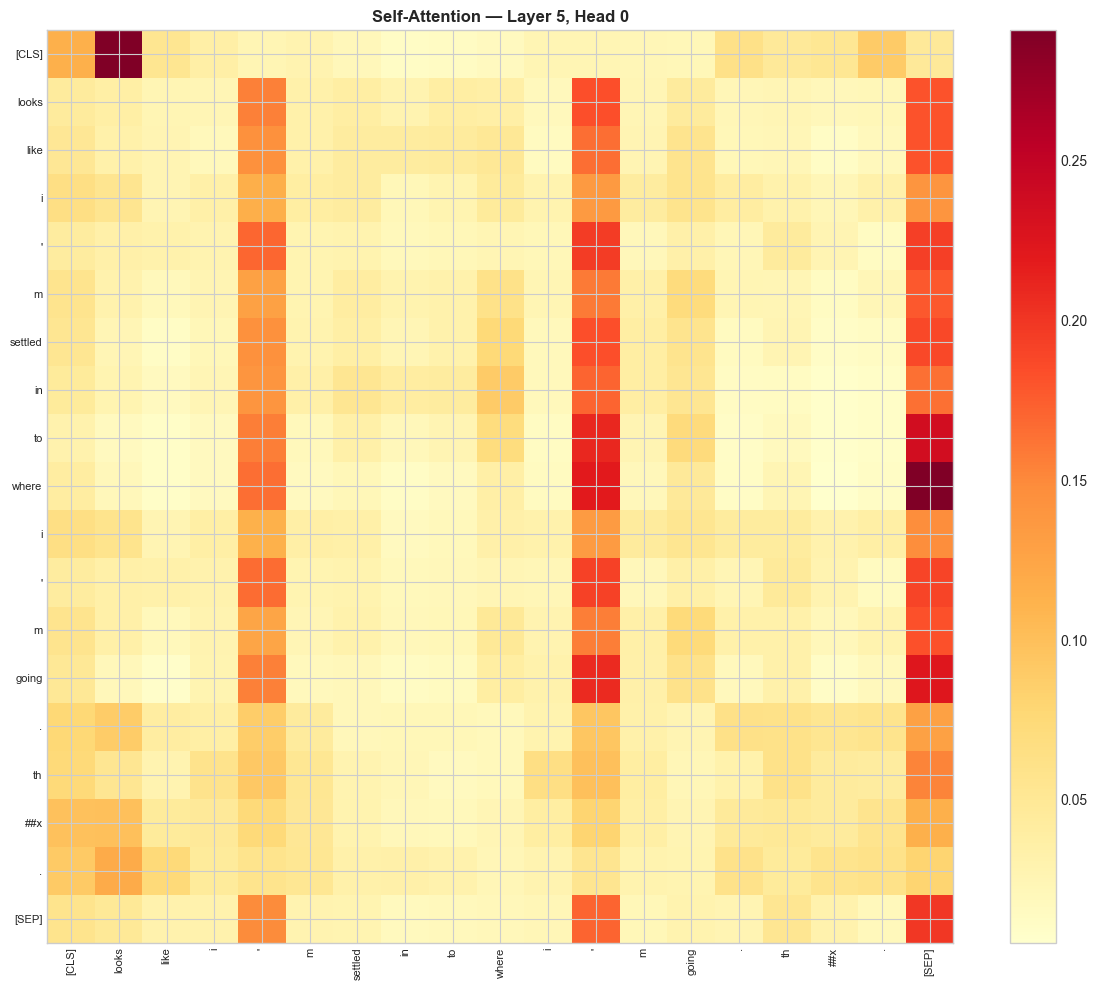

Figure saved: ../outputs/figures/04_attention_layer5_head0.png


In [9]:
import matplotlib.pyplot as plt

def visualize_attention(text, model, tokenizer, max_len=64, layer=5, head=0):
    """Show self-attention weights for a single tweet (layer / head selectable)."""
    enc = tokenizer(
        text, max_length=max_len, truncation=True,
        padding='max_length', return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    model.eval()
    with torch.no_grad():
        base_out = model.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
        )

    attentions = base_out.attentions          # tuple, one tensor per layer
    num_layers = len(attentions)
    print(f'  num attention layers: {num_layers}')
    layer = min(layer, num_layers - 1)
    attn  = attentions[layer][0, head].cpu().numpy()

    tokens   = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    real_len = int(attention_mask[0].sum().item())
    tokens   = tokens[:real_len]
    attn     = attn[:real_len, :real_len]

    fig, ax = plt.subplots(figsize=(min(12, real_len * 0.65), min(10, real_len * 0.55)))
    im = ax.imshow(attn, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(real_len))
    ax.set_yticks(range(real_len))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Self-Attention — Layer {layer}, Head {head}', fontsize=12, fontweight='bold')
    plt.colorbar(im)
    plt.tight_layout()
    save_path = f'{FIGURES_DIR}/04_attention_layer{layer}_head{head}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {save_path}')

# Positive example
pos_sample = X_test[y_test == 1][0]
print('Positive tweet:', pos_sample)
visualize_attention(pos_sample, model, tokenizer, layer=5, head=0)

Negative tweet: Sitting at the gate on Flight 719 for an hour due to Sabre being down. What backup plan is in place if Sabre cannot be fixed?
  num attention layers: 6


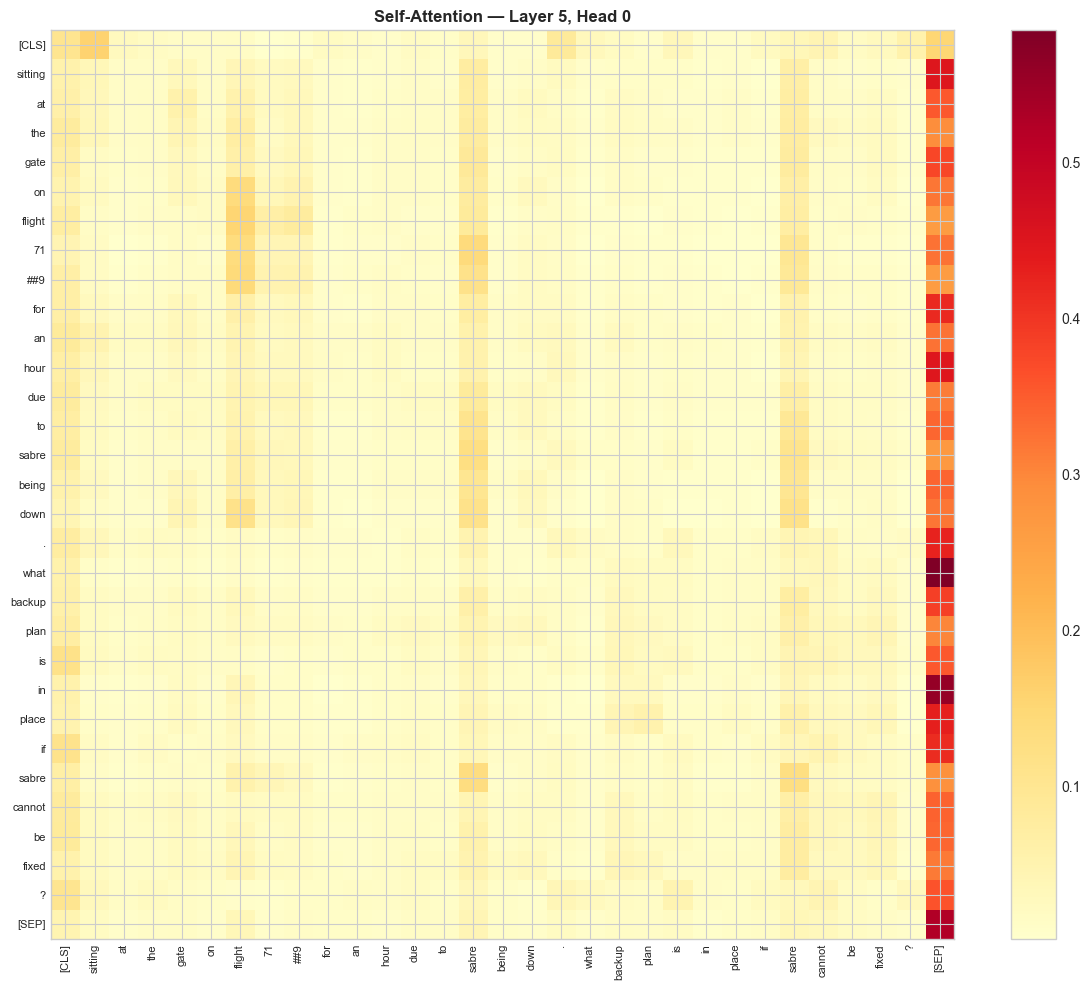

Figure saved: ../outputs/figures/04_attention_layer5_head0.png


In [10]:
# Negative example
neg_sample = X_test[y_test == 0][0]
print('Negative tweet:', neg_sample)
visualize_attention(neg_sample, model, tokenizer, layer=5, head=0)

## 6. Full Model Comparison

We now add the DistilBERT results to the comparison table from notebook 03.

In [11]:
import pandas as pd

base_df = pd.read_csv(f'{METRICS_DIR}/model_comparison.csv')

transformer_row = pd.DataFrame([{
    'Model': 'DistilBERT',
    'Accuracy': transformer_metrics['accuracy'],
    'Precision': transformer_metrics['precision'],
    'Recall': transformer_metrics['recall'],
    'F1-Score': transformer_metrics['f1_score'],
    'Cohen Kappa': transformer_metrics['cohen_kappa'],
}])

full_df = pd.concat([base_df, transformer_row], ignore_index=True)
full_df = full_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
full_df.to_csv(f'{METRICS_DIR}/full_model_comparison.csv', index=False)

print(full_df.to_string(index=False))

          Model  Accuracy  Precision  Recall  F1-Score  Cohen Kappa
     DistilBERT    0.9200     0.9286  0.9100    0.9192       0.8400
    Vanilla RNN    0.7291     0.7177  0.7617    0.7391       0.4579
       Dense NN    0.7073     0.8333  0.5235    0.6430       0.4161
   LSTM (tuned)    0.5055     0.5046  1.0000    0.6707       0.0037
DummyClassifier    0.5036     0.5036  1.0000    0.6699       0.0000
           LSTM    0.5036     0.5036  1.0000    0.6699       0.0000


## 7. Transformer vs RNN/LSTM — Conceptual Analysis

### Computational Model Differences

| Property | Vanilla RNN | LSTM | Transformer (DistilBERT) |
|----------|------------|------|-------------------------|
| Processing order | Strictly sequential | Strictly sequential | Fully parallel |
| Long-range memory | Poor (vanishing gradient) | Better (gated cell) | Excellent (direct attention) |
| Context window | Hidden state (fixed size) | Cell state (gated) | Full sequence (all pairs) |
| Parameters | ~330K | ~355K | ~67M (pre-trained) |
| Training data needed | Large (from scratch) | Large (from scratch) | Small (fine-tuning) |
| Interpretability | Low (hidden state) | Low (cell state) | Moderate (attention maps) |

### Why DistilBERT outperforms custom RNN/LSTM on small datasets

1. **Transfer learning:** Pre-trained on billions of tokens — deep linguistic knowledge is
   already encoded in the weights. Fine-tuning on 800 tweets only needs to adapt the
   output head and slightly adjust attention patterns.

2. **Bidirectional context:** DistilBERT reads the entire tweet before building any
   representation. An LSTM reads left-to-right; by the time it processes "great" in
   "not great service", the negation information may be weakened.
   DistilBERT attends to "not" and "great" simultaneously.

3. **Subword tokenization:** WordPiece handles out-of-vocabulary words gracefully
   (e.g., airline-specific jargon) by splitting into known subunits.

### TM Analysis

The Transformer's attention mechanism can be interpreted as a **content-addressable memory**:
rather than reading the tape linearly like an RNN, it can jump to any relevant position in
one step. This is analogous to a non-deterministic TM that can "guess" the relevant part
of the input tape in a single transition, giving it strictly greater expressive power than
recurrent architectures with bounded memory.